In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [41]:
DATASET_NAME = "monthly_ff5"

MODEL_DIR = Path("../models") / DATASET_NAME
FEATURE_DIR = Path("../data/features") / DATASET_NAME
RESULTS_DIR = Path("../results") / DATASET_NAME / "backtest"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [42]:
predictions = pd.read_csv(
    MODEL_DIR / "test_probabilities.csv"
)

meta_test = pd.read_csv(
    FEATURE_DIR / "meta_test.csv",
    parse_dates=["Date", "RealizationDate"]
)

backtest_data = pd.concat(
    [
        meta_test.reset_index(drop=True),
        predictions.reset_index(drop=True)
    ],
    axis=1
)

display(backtest_data.head())

,Date,RealizationDate,Portfolio,RealizedNextReturn,actual_label,xgb_signature_prob,xgb_garch_prob,xgb_combined_prob,cnn_signature_prob,cnn_garch_prob,cnn_combined_prob,ensemble_signature_prob,ensemble_garch_prob,ensemble_combined_prob
0,2016-12-01,2017-01-01,SMALL LoBM,1.8952,0,0.209247,0.441335,0.252384,0.506218,0.470946,0.491469,0.253793,0.466504,0.467561
1,2016-12-01,2017-01-01,ME1 BM2,-3.9144,0,0.285038,0.429866,0.395461,0.505686,0.476180,0.493874,0.318135,0.469233,0.484033
2,2016-12-01,2017-01-01,ME1 BM3,-0.1916,0,0.260749,0.681254,0.331918,0.505159,0.489069,0.501536,0.297411,0.517897,0.484574
3,2016-12-01,2017-01-01,ME1 BM4,-1.8426,0,0.459099,0.415666,0.403396,0.502466,0.485010,0.497425,0.465605,0.474608,0.488022
4,2016-12-01,2017-01-01,SMALL HiBM,-0.1450,0,0.277654,0.650161,0.309840,0.503440,0.487060,0.499964,0.311522,0.511525,0.480952


In [43]:
def build_top_k_strategy(
    data,
    probability_column,
    k=5
):
    """
    Select the k portfolios with the highest predicted probabilities
    at each date and calculate their equal-weighted realized return.
    """

    records = []

    for date, group in data.groupby("Date"):
        selected = group.nlargest(k, probability_column)

        strategy_return = selected[
            "RealizedNextReturn"
        ].mean()

        records.append({
            "Date": date,
            "StrategyReturn": strategy_return,
            "SelectedPortfolios": ", ".join(
                selected["Portfolio"].astype(str)
            )
        })

    return pd.DataFrame(records).sort_values("Date")

In [44]:
ensemble_combined_strategy = build_top_k_strategy(
    data=backtest_data,
    probability_column="ensemble_combined_prob",
    k=5
)

display(ensemble_combined_strategy.head())

,Date,StrategyReturn,SelectedPortfolios
0,2016-12-01,-0.60784,"ME2 BM4, ME3 BM4, ME3 BM5, ME2 BM5, ME1 BM4"
1,2017-01-01,2.04358,"ME1 BM4, BIG HiBM, ME5 BM4, ME1 BM2, ME3 BM5"
2,2017-02-01,-1.00666,"ME3 BM5, ME4 BM3, ME3 BM4, ME4 BM5, ME3 BM3"
3,2017-03-01,1.10876,"ME2 BM1, BIG HiBM, ME5 BM2, ME4 BM5, ME2 BM4"
4,2017-04-01,-2.66566,"ME2 BM1, ME3 BM4, ME2 BM4, SMALL HiBM, ME3 BM5"


In [45]:
PROBABILITY_COLUMNS = {
    "XGBoost Signature": "xgb_signature_prob",
    "XGBoost GARCH": "xgb_garch_prob",
    "XGBoost Combined": "xgb_combined_prob",

    "CNN Signature": "cnn_signature_prob",
    "CNN GARCH": "cnn_garch_prob",
    "CNN Combined": "cnn_combined_prob",

    "Ensemble Signature": "ensemble_signature_prob",
    "Ensemble GARCH": "ensemble_garch_prob",
    "Ensemble Combined": "ensemble_combined_prob",
}

In [46]:
backtest_data = pd.concat(
    [
        meta_test.reset_index(drop=True),
        predictions.reset_index(drop=True)
    ],
    axis=1
)

print(backtest_data.columns.tolist())

backtest_data["RealizedNextReturn"] = (
    backtest_data["RealizedNextReturn"] / 100.0
)

['Date', 'RealizationDate', 'Portfolio', 'RealizedNextReturn', 'actual_label', 'xgb_signature_prob', 'xgb_garch_prob', 'xgb_combined_prob', 'cnn_signature_prob', 'cnn_garch_prob', 'cnn_combined_prob', 'ensemble_signature_prob', 'ensemble_garch_prob', 'ensemble_combined_prob']


In [47]:
strategies = {}

for model_name, probability_column in PROBABILITY_COLUMNS.items():
    strategies[model_name] = build_top_k_strategy(
        data=backtest_data,
        probability_column=probability_column,
        k=5
    )

In [48]:
display(strategies["Ensemble Combined"].head())

,Date,StrategyReturn,SelectedPortfolios
0,2016-12-01,-0.006078,"ME2 BM4, ME3 BM4, ME3 BM5, ME2 BM5, ME1 BM4"
1,2017-01-01,0.020436,"ME1 BM4, BIG HiBM, ME5 BM4, ME1 BM2, ME3 BM5"
2,2017-02-01,-0.010067,"ME3 BM5, ME4 BM3, ME3 BM4, ME4 BM5, ME3 BM3"
3,2017-03-01,0.011088,"ME2 BM1, BIG HiBM, ME5 BM2, ME4 BM5, ME2 BM4"
4,2017-04-01,-0.026657,"ME2 BM1, ME3 BM4, ME2 BM4, SMALL HiBM, ME3 BM5"


In [49]:
for model_name, strategy in strategies.items():
    strategy["CumulativeValue"] = (
        1 + strategy["StrategyReturn"]
    ).cumprod()

display(strategies["Ensemble Combined"].head())

,Date,StrategyReturn,SelectedPortfolios,CumulativeValue
0,2016-12-01,-0.006078,"ME2 BM4, ME3 BM4, ME3 BM5, ME2 BM5, ME1 BM4",0.993922
1,2017-01-01,0.020436,"ME1 BM4, BIG HiBM, ME5 BM4, ME1 BM2, ME3 BM5",1.014233
2,2017-02-01,-0.010067,"ME3 BM5, ME4 BM3, ME3 BM4, ME4 BM5, ME3 BM3",1.004023
3,2017-03-01,0.011088,"ME2 BM1, BIG HiBM, ME5 BM2, ME4 BM5, ME2 BM4",1.015156
4,2017-04-01,-0.026657,"ME2 BM1, ME3 BM4, ME2 BM4, SMALL HiBM, ME3 BM5",0.988095


In [50]:
def calculate_performance_statistics(
    strategy_returns,
    periods_per_year=12,
    risk_free_rate=0.0
):
    """
    Calculate annualized return, volatility, Sharpe ratio,
    cumulative return, and maximum drawdown.
    """

    returns = pd.Series(strategy_returns).dropna()

    if len(returns) == 0:
        raise ValueError("No valid strategy returns were provided.")

    cumulative_value = (1 + returns).cumprod()

    annualized_return = (
        cumulative_value.iloc[-1] ** (periods_per_year / len(returns))
    ) - 1

    annualized_volatility = (
        returns.std(ddof=1) * np.sqrt(periods_per_year)
    )

    annualized_excess_return = annualized_return - risk_free_rate

    sharpe_ratio = (
        annualized_excess_return / annualized_volatility
        if annualized_volatility > 0
        else np.nan
    )

    running_max = cumulative_value.cummax()
    drawdown = cumulative_value / running_max - 1
    maximum_drawdown = drawdown.min()

    total_return = cumulative_value.iloc[-1] - 1

    return {
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": maximum_drawdown
    }

In [51]:
performance_records = []

for model_name, strategy in strategies.items():
    stats = calculate_performance_statistics(
        strategy_returns=strategy["StrategyReturn"],
        periods_per_year=12
    )

    stats["Model"] = model_name
    performance_records.append(stats)

performance_table = pd.DataFrame(performance_records)

performance_table = performance_table[
    [
        "Model",
        "Total Return",
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown"
    ]
].sort_values(
    by="Sharpe Ratio",
    ascending=False
).reset_index(drop=True)

display(
    performance_table.style.format({
        "Total Return": "{:.2%}",
        "Annualized Return": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Maximum Drawdown": "{:.2%}"
    })
)

,Model,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
0,CNN GARCH,219.04%,13.24%,19.52%,0.678,-26.50%
1,XGBoost Signature,220.42%,13.29%,20.00%,0.664,-30.31%
2,Ensemble Signature,219.68%,13.26%,20.01%,0.663,-30.31%
3,CNN Signature,247.43%,14.27%,21.81%,0.654,-31.86%
4,XGBoost Combined,214.76%,13.07%,21.51%,0.608,-34.29%
5,Ensemble GARCH,175.07%,11.45%,20.52%,0.558,-34.34%
6,CNN Combined,185.21%,11.88%,22.06%,0.539,-33.01%
7,Ensemble Combined,184.68%,11.86%,22.42%,0.529,-37.56%
8,XGBoost GARCH,168.51%,11.16%,21.19%,0.527,-34.97%


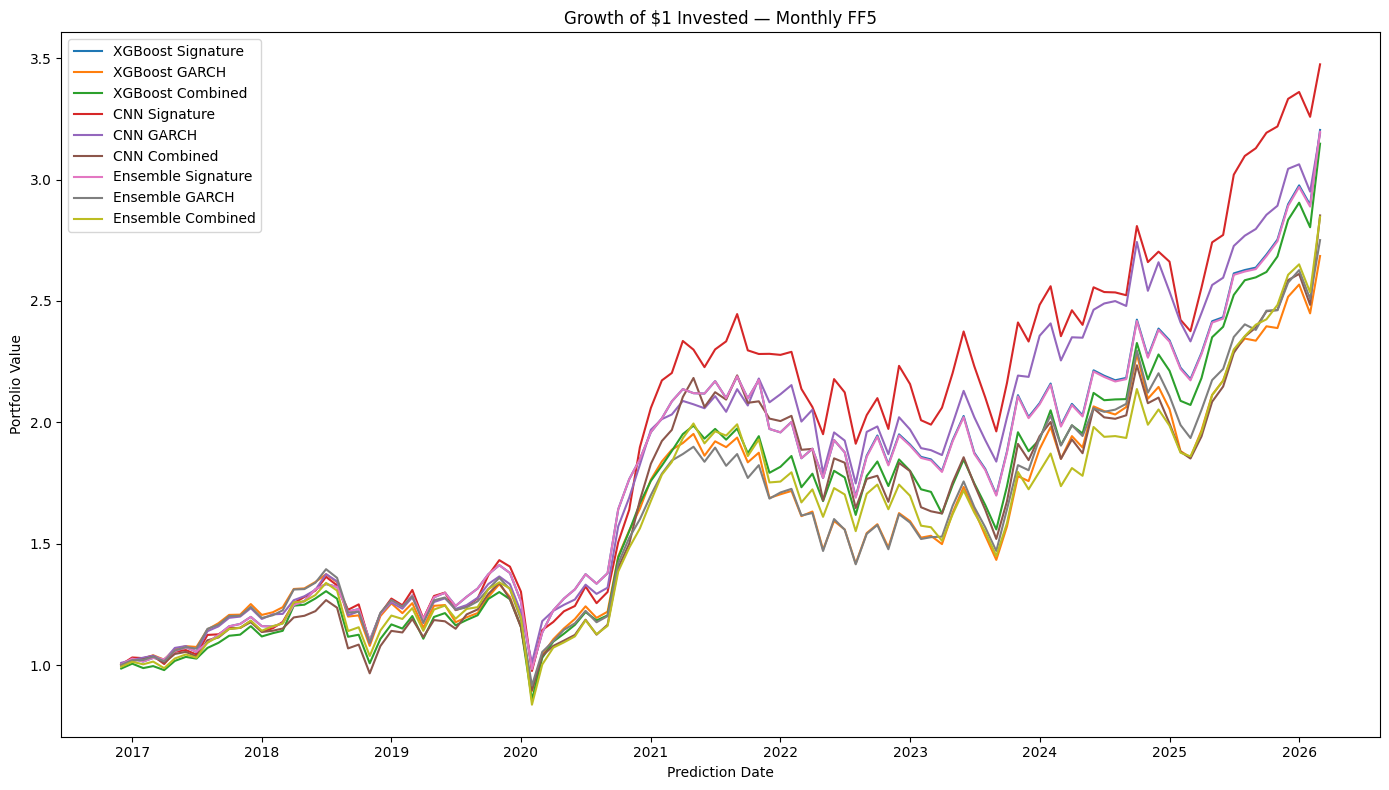

In [52]:
plt.figure(figsize=(14, 8))

for model_name, strategy in strategies.items():
    plt.plot(
        strategy["Date"],
        strategy["CumulativeValue"],
        label=model_name
    )

plt.title("Growth of $1 Invested — Monthly FF5")
plt.xlabel("Prediction Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
equal_weight_benchmark = (
    backtest_data
    .groupby("Date", as_index=False)["RealizedNextReturn"]
    .mean()
    .rename(
        columns={
            "RealizedNextReturn": "StrategyReturn"
        }
    )
)

equal_weight_benchmark["CumulativeValue"] = (
    1 + equal_weight_benchmark["StrategyReturn"]
).cumprod()

display(equal_weight_benchmark.head())

,Date,StrategyReturn,CumulativeValue
0,2016-12-01,0.008660,1.008660
1,2017-01-01,0.022187,1.031039
2,2017-02-01,0.001137,1.032212
3,2017-03-01,0.009270,1.041781
4,2017-04-01,-0.012526,1.028731


In [54]:
benchmark_stats = calculate_performance_statistics(
    strategy_returns=equal_weight_benchmark["StrategyReturn"],
    periods_per_year=12
)

benchmark_stats["Model"] = "Equal-Weight 25 Portfolios"

performance_table = pd.concat(
    [
        performance_table,
        pd.DataFrame([benchmark_stats])
    ],
    ignore_index=True
)

performance_table = performance_table[
    [
        "Model",
        "Total Return",
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown"
    ]
].sort_values(
    by="Sharpe Ratio",
    ascending=False
).reset_index(drop=True)

display(
    performance_table.style.format({
        "Total Return": "{:.2%}",
        "Annualized Return": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Maximum Drawdown": "{:.2%}"
    })
)

,Model,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
0,CNN GARCH,219.04%,13.24%,19.52%,0.678,-26.50%
1,XGBoost Signature,220.42%,13.29%,20.00%,0.664,-30.31%
2,Ensemble Signature,219.68%,13.26%,20.01%,0.663,-30.31%
3,CNN Signature,247.43%,14.27%,21.81%,0.654,-31.86%
4,XGBoost Combined,214.76%,13.07%,21.51%,0.608,-34.29%
5,Equal-Weight 25 Portfolios,188.73%,12.03%,19.94%,0.603,-30.83%
6,Ensemble GARCH,175.07%,11.45%,20.52%,0.558,-34.34%
7,CNN Combined,185.21%,11.88%,22.06%,0.539,-33.01%
8,Ensemble Combined,184.68%,11.86%,22.42%,0.529,-37.56%
9,XGBoost GARCH,168.51%,11.16%,21.19%,0.527,-34.97%


In [55]:
print(backtest_data["RealizedNextReturn"].describe())

print(
    backtest_data["RealizedNextReturn"]
    .sort_values()
    .head(10)
)

print(
    backtest_data["RealizedNextReturn"]
    .sort_values(ascending=False)
    .head(10)
)

count    2800.000000
mean        0.011169
std         0.063720
min        -0.325184
25%        -0.025302
50%         0.014028
75%         0.046579
max         0.412114
Name: RealizedNextReturn, dtype: float64
969   -0.325184
968   -0.320833
959   -0.319728
964   -0.311937
974   -0.284596
954   -0.276923
963   -0.265460
953   -0.264965
958   -0.235720
952   -0.218594
Name: RealizedNextReturn, dtype: float64
1204    0.412114
2799    0.316629
984     0.259626
1150    0.257600
1154    0.245286
975     0.243389
1164    0.229243
1174    0.219976
1155    0.214791
1151    0.214574
Name: RealizedNextReturn, dtype: float64


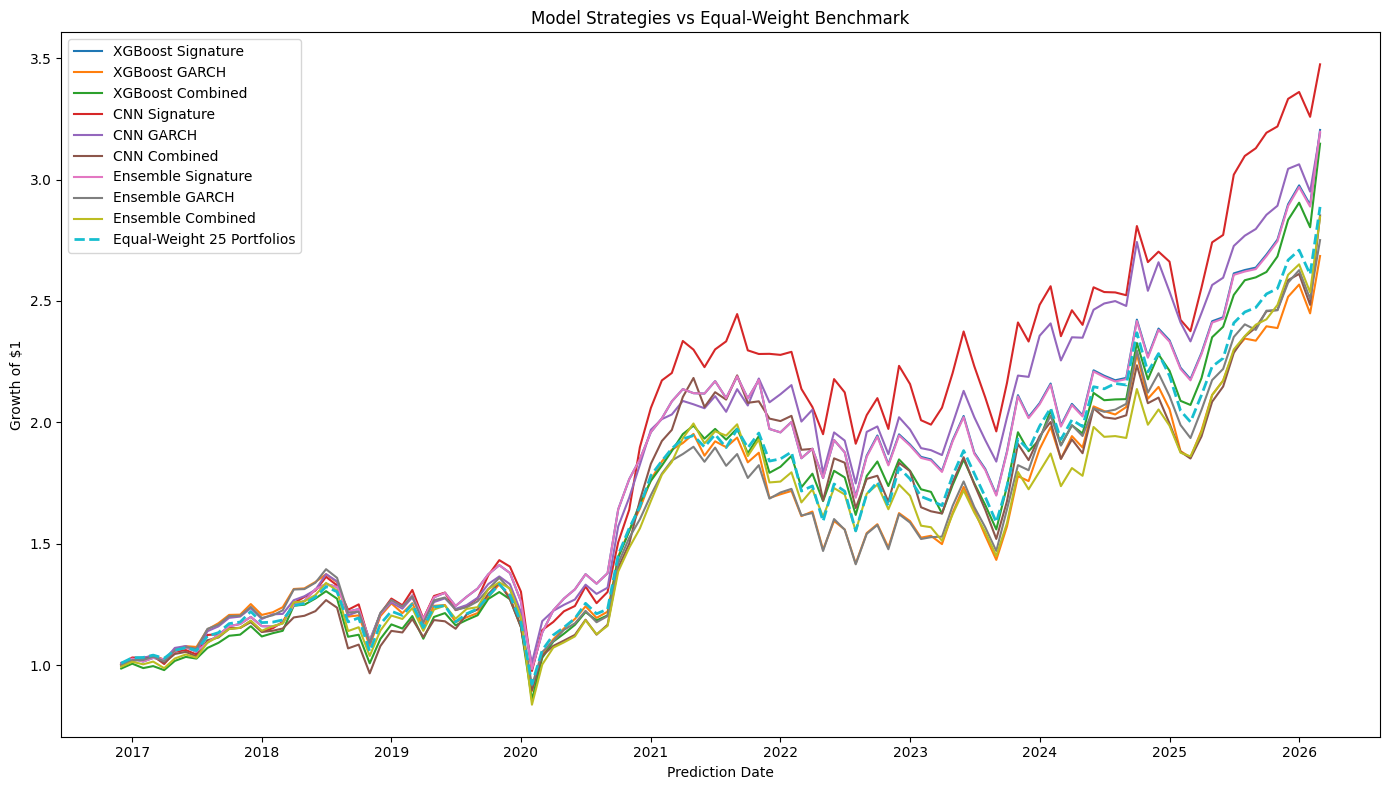

In [56]:
plt.figure(figsize=(14, 8))

for model_name, strategy in strategies.items():
    plt.plot(
        strategy["Date"],
        strategy["CumulativeValue"],
        label=model_name
    )

plt.plot(
    equal_weight_benchmark["Date"],
    equal_weight_benchmark["CumulativeValue"],
    linestyle="--",
    linewidth=2,
    label="Equal-Weight 25 Portfolios"
)

plt.title("Model Strategies vs Equal-Weight Benchmark")
plt.xlabel("Prediction Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
BACKTEST_DIR = Path("../results/monthly_ff5/backtest")
BACKTEST_DIR.mkdir(parents=True, exist_ok=True)

performance_table.to_csv(
    BACKTEST_DIR / "performance_summary.csv",
    index=False
)

equal_weight_benchmark.to_csv(
    BACKTEST_DIR / "equal_weight_benchmark.csv",
    index=False
)

for model_name, strategy in strategies.items():
    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("/", "_")
    )

    strategy.to_csv(
        BACKTEST_DIR / f"{safe_name}_strategy.csv",
        index=False
    )

print("Backtest results saved to:", BACKTEST_DIR.resolve())

Backtest results saved to: C:\Users\kyler\Documents\VS_Code\Finance Code\ML using FAMA and FRENCH\results\monthly_ff5\backtest


In [58]:
metric_summary = {}

metrics = [
    "Annualized Return",
    "Sharpe Ratio",
    "Maximum Drawdown",
    "Total Return"
]

for metric in metrics:

    if metric == "Maximum Drawdown":
        best = performance_table.loc[
            performance_table[metric].idxmax()
        ]
    else:
        best = performance_table.loc[
            performance_table[metric].idxmax()
        ]

    metric_summary[metric] = {
        "Best Model": best["Model"],
        "Value": best[metric]
    }

metric_summary = pd.DataFrame(metric_summary).T

display(metric_summary)

,Best Model,Value
Annualized Return,CNN Signature,0.142746
Sharpe Ratio,CNN GARCH,0.67788
Maximum Drawdown,CNN GARCH,-0.265021
Total Return,CNN Signature,2.474285


In [59]:
feature_summary = performance_table.copy()

feature_summary["Feature Type"] = (
    feature_summary["Model"]
    .str.extract(r"(Signature|GARCH|Combined)")
)

feature_summary = (
    feature_summary
    .groupby("Feature Type")
    .mean(numeric_only=True)
)

display(feature_summary)

,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
Feature Type,,,,,
Combined,1.948858,0.122726,0.219989,0.558450,-0.349552
GARCH,1.875400,0.119498,0.204108,0.587598,-0.319375
Signature,2.291753,0.136076,0.206077,0.660493,-0.308261


In [60]:
architecture_summary = performance_table.copy()

architecture_summary["Architecture"] = (
    architecture_summary["Model"]
    .str.extract(r"^(CNN|XGBoost|Ensemble)")
)

architecture_summary = (
    architecture_summary
    .groupby("Architecture")
    .mean(numeric_only=True)
)

display(architecture_summary)

,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
Architecture,,,,,
CNN,2.172260,0.131314,0.211339,0.623638,-0.304572
Ensemble,1.931443,0.121909,0.209835,0.583253,-0.340717
XGBoost,2.012308,0.125077,0.208999,0.599649,-0.331900


In [61]:
winner = performance_table.iloc[0]

print("=" * 60)
print("BEST MODEL")
print("=" * 60)

display(winner)

BEST MODEL


Model                    CNN GARCH
Total Return              2.190369
Annualized Return         0.132356
Annualized Volatility      0.19525
Sharpe Ratio               0.67788
Maximum Drawdown         -0.265021
Name: 0, dtype: object

In [62]:
metric_summary.to_csv(
    BACKTEST_DIR / "metric_summary.csv"
)

feature_summary.to_csv(
    BACKTEST_DIR / "feature_summary.csv"
)

architecture_summary.to_csv(
    BACKTEST_DIR / "architecture_summary.csv"
)